In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from IPython.display import display, clear_output
import os

# ====== PATH CONFIGURATION ======
BASE_PATH = '/Users/clttoolboxmacm1/Documents/1. Mechine Learning/undervalued_soccer/'

folder_path = BASE_PATH

# 2. Loop melalui semua file di dalam folder tersebut
print(f"Membaca file dari: {folder_path}\n")

for filename in os.listdir(folder_path):
    # Cek apakah file tersebut berakhiran .csv
    if filename.endswith(".csv"):
        file_path = os.path.join(folder_path, filename)
        
        # 3. Baca file CSV
        try:
            df = pd.read_csv(file_path)
            
            # 4. Tampilkan Judul dan Info
            print(f"📘 FILE: {filename}")
            print(f"Dimensi Data: {df.shape} (Baris, Kolom)")
            
            # 5. Tampilkan 5 baris pertama (menggunakan display agar format tabel bagus)
            display(df.head())
            
            print("="*80 + "\n") # Garis pemisah antar tabel
            
        except Exception as e:
            print(f"Gagal membaca {filename}: {e}")

# Konfigurasi Tampilan
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style("whitegrid")
# Font scale diperbesar untuk standar publikasi jurnal (agar terbaca saat di-resize)
sns.set_context("paper", font_scale=1.5) 
plt.rcParams['figure.figsize'] = (12, 7)

print("🚀 Memulai Proses Big Data Analytics pada Dataset Transfermarkt...")

Membaca file dari: /Users/clttoolboxmacm1/Documents/1. Mechine Learning/undervalued_soccer/

📘 FILE: game_lineups.csv
Dimensi Data: (2191911, 10) (Baris, Kolom)
📘 FILE: game_lineups.csv
Dimensi Data: (2191911, 10) (Baris, Kolom)


,game_lineups_id,date,game_id,player_id,club_id,player_name,type,position,number,team_captain
0,b2dbe01c3656b06c8e23e9de714e26bb,2013-07-27,2317258,1443,610,Christian Poulsen,substitutes,Defensive Midfield,5,0
1,b50a3ec6d52fd1490aab42042ac4f738,2013-07-27,2317258,5017,610,Niklas Moisander,starting_lineup,Centre-Back,4,0
2,7d890e6d0ff8af84b065839966a0ec81,2013-07-27,2317258,9602,1090,Maarten Martens,substitutes,Left Winger,11,0
3,8c355268678b9bbc7084221b1f0fde36,2013-07-27,2317258,12282,610,Daley Blind,starting_lineup,Left-Back,17,0
4,76193074d549e5fdce4cdcbba0d66247,2013-07-27,2317258,25427,1090,Roy Beerens,starting_lineup,Right Winger,23,0



📘 FILE: competitions.csv
Dimensi Data: (44, 11) (Baris, Kolom)


,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,url,is_major_national_league
0,CIT,italy-cup,italy-cup,domestic_cup,domestic_cup,75,Italy,IT1,europa,https://www.transfermarkt.co.uk/italy-cup/star...,False
1,NLSC,johan-cruijff-schaal,johan-cruijff-schaal,domestic_super_cup,other,122,Netherlands,NL1,europa,https://www.transfermarkt.co.uk/johan-cruijff-...,False
2,GRP,kypello-elladas,kypello-elladas,domestic_cup,domestic_cup,56,Greece,GR1,europa,https://www.transfermarkt.co.uk/kypello-ellada...,False
3,POSU,supertaca-candido-de-oliveira,supertaca-candido-de-oliveira,domestic_super_cup,other,136,Portugal,PO1,europa,https://www.transfermarkt.co.uk/supertaca-cand...,False
4,RUSS,russian-super-cup,russian-super-cup,domestic_super_cup,other,141,Russia,RU1,europa,https://www.transfermarkt.co.uk/russian-super-...,False



📘 FILE: appearances.csv
Dimensi Data: (1706806, 13) (Baris, Kolom)
📘 FILE: appearances.csv
Dimensi Data: (1706806, 13) (Baris, Kolom)


...


📘 FILE: club_games.csv
Dimensi Data: (148052, 11) (Baris, Kolom)


,game_id,club_id,own_goals,own_position,own_manager_name,opponent_id,opponent_goals,opponent_position,opponent_manager_name,hosting,is_win
0,2320450,1468.000,0.000,NaN,Holger Bachthaler,24.000,2.000,NaN,Armin Veh,Home,0
1,2320454,222.000,0.000,NaN,Volkan Uluc,79.000,2.000,NaN,Bruno Labbadia,Home,0
2,2320460,1.000,3.000,NaN,Jürgen Luginger,86.000,1.000,NaN,Robin Dutt,Home,1
3,2320472,2036.000,4.000,NaN,Frank Schmidt,72.000,5.000,NaN,Alexander Schmidt,Home,0
4,2321027,33.000,3.000,8.000,Jens Keller,41.000,3.000,9.000,Thorsten Fink,Home,0



📘 FILE: clubs.csv
Dimensi Data: (439, 17) (Baris, Kolom)


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,105,sv-darmstadt-98,SV Darmstadt 98,L1,NaN,27,25.600,13,48.100,1,Merck-Stadion am Böllenfalltor,17810,+€3.05m,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/sv-darmstadt-9...
1,11127,ural-ekaterinburg,Ural Yekaterinburg,RU1,NaN,30,26.500,11,36.700,3,Yekaterinburg Arena,23000,+€880k,NaN,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/ural-ekaterinb...
2,114,besiktas-istanbul,Beşiktaş Jimnastik Kulübü,TR1,NaN,30,26.600,15,50.000,8,Beşiktaş Park,42445,€-25.26m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/besiktas-istan...
3,12,as-rom,Associazione Sportiva Roma,IT1,NaN,26,26.300,18,69.200,17,Olimpico di Roma,70634,€-76.90m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/as-rom/startse...
4,148,tottenham-hotspur,Tottenham Hotspur Football Club,GB1,NaN,30,25.500,21,70.000,18,Tottenham Hotspur Stadium,62850,€-120.05m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/tottenham-hots...



🚀 Memulai Proses Big Data Analytics pada Dataset Transfermarkt...


In [9]:
# ==================================================================================================
# TAHAP 1: AKUISISI DAN INTEGRASI DATA MASIF
# ==================================================================================================
print("\n[TAHAP 1] Loading & Merging Data...")

# 1. Load Data Utama
df_players = pd.read_csv(f'{BASE_PATH}players.csv', parse_dates=['date_of_birth', 'contract_expiration_date'])
df_appearances = pd.read_csv(f'{BASE_PATH}appearances.csv', parse_dates=['date'])
df_valuations = pd.read_csv(f'{BASE_PATH}player_valuations.csv', parse_dates=['date'])
df_clubs = pd.read_csv(f'{BASE_PATH}clubs.csv')
df_competitions = pd.read_csv(f'{BASE_PATH}competitions.csv')

print(f"-> Players loaded: {df_players.shape}")
print(f"-> Appearances loaded: {df_appearances.shape}")

# 2. Mendapatkan Market Value TERBARU
latest_valuations = df_valuations.sort_values('date').groupby('player_id').last().reset_index()
latest_valuations = latest_valuations[['player_id', 'market_value_in_eur', 'date']]
latest_valuations.rename(columns={'date': 'valuation_date'}, inplace=True)

# 3. Agregasi Statistik Performa (2 Musim Terakhir)
max_date = df_appearances['date'].max()
start_date = max_date - pd.DateOffset(years=2)

print(f"-> Memfilter performa dari {start_date.date()} sampai {max_date.date()}")
recent_appearances = df_appearances[df_appearances['date'] >= start_date]

player_stats = recent_appearances.groupby('player_id').agg({
    'goals': 'sum',
    'assists': 'sum',
    'yellow_cards': 'sum',
    'red_cards': 'sum',
    'minutes_played': 'sum',
    'game_id': 'count',
    'competition_id': lambda x: x.mode()[0] if not x.mode().empty else np.nan
}).reset_index()
player_stats.rename(columns={'game_id': 'appearances_count'}, inplace=True)

# 4. Penggabungan Tabel (Merging)
if 'market_value_in_eur' in df_players.columns:
    df_players = df_players.drop(columns=['market_value_in_eur'])

df_master = df_players.merge(player_stats, on='player_id', how='inner')
df_master = df_master.merge(latest_valuations, on='player_id', how='inner')
df_master = df_master.merge(df_clubs[['club_id', 'total_market_value', 'domestic_competition_id']], 
                            left_on='current_club_id', right_on='club_id', how='left')

df_master = df_master.dropna(subset=['market_value_in_eur'])
df_master = df_master[df_master['minutes_played'] > 500]

print(f"-> Total Dataset Bersih untuk Modeling: {df_master.shape[0]} pemain")


[TAHAP 1] Loading & Merging Data...
-> Players loaded: (32601, 23)
-> Appearances loaded: (1706806, 13)
-> Memfilter performa dari 2023-04-10 sampai 2025-04-10
-> Players loaded: (32601, 23)
-> Appearances loaded: (1706806, 13)
-> Memfilter performa dari 2023-04-10 sampai 2025-04-10
-> Total Dataset Bersih untuk Modeling: 6780 pemain
-> Total Dataset Bersih untuk Modeling: 6780 pemain


In [10]:
# ==================================================================================================
# TAHAP 2: FEATURE ENGINEERING
# ==================================================================================================
print("\n[TAHAP 2] Feature Engineering & Normalisasi...")

# Umur
reference_date = datetime.now()
df_master['age'] = (reference_date - df_master['date_of_birth']).dt.days / 365.25

# Sisa Kontrak
df_master['contract_expiration_date'] = pd.to_datetime(df_master['contract_expiration_date'], errors='coerce')
df_master['days_left_contract'] = (df_master['contract_expiration_date'] - reference_date).dt.days
df_master['days_left_contract'] = df_master['days_left_contract'].fillna(365)
df_master['years_left_contract'] = df_master['days_left_contract'] / 365.0
df_master.loc[df_master['years_left_contract'] < 0, 'years_left_contract'] = 0

# Metrik Per 90 Menit
df_master['goals_per_90'] = (df_master['goals'] / df_master['minutes_played']) * 90
df_master['assists_per_90'] = (df_master['assists'] / df_master['minutes_played']) * 90
df_master['cards_per_90'] = ((df_master['yellow_cards'] + df_master['red_cards']) / df_master['minutes_played']) * 90
df_master['involvement_per_90'] = df_master['goals_per_90'] + df_master['assists_per_90']

# Log-Transformation Target
df_master['log_market_value'] = np.log1p(df_master['market_value_in_eur'])

# Fill NaN Categorical
cat_cols_to_fill = ['position', 'sub_position', 'foot', 'competition_id', 'country_of_citizenship']
for col in cat_cols_to_fill:
    df_master[col] = df_master[col].fillna('Unknown').astype(str)



[TAHAP 2] Feature Engineering & Normalisasi...


In [11]:
# ==================================================================================================
# TAHAP 3: PEMODELAN (CATBOOST)
# ==================================================================================================
print("\n[TAHAP 3] Training CatBoost Regressor...")

features_cat = ['position', 'sub_position', 'foot', 'competition_id', 'country_of_citizenship']
features_num = ['age', 'height_in_cm', 'years_left_contract', 
                'goals_per_90', 'assists_per_90', 'involvement_per_90', 'minutes_played', 
                'total_market_value']

for col in features_num:
    df_master[col] = df_master[col].fillna(df_master[col].median())

X = df_master[features_num + features_cat]
y = df_master['log_market_value']

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='R2',
    cat_features=features_cat,
    verbose=0,
    random_seed=42
)



[TAHAP 3] Training CatBoost Regressor...


In [12]:
# ==================================================================================================
# TAHAP 4: VALIDASI (5-FOLD CV)
# ==================================================================================================
print("\n[TAHAP 4] Validasi 5-Fold Cross Validation & Analisis Residu...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    
    val_preds = cat_model.predict(X_val)
    oof_preds[val_idx] = val_preds
    
    score = r2_score(y_val, val_preds)
    r2_scores.append(score)
    print(f"   Fold {fold+1}: R2 Score = {score:.4f}")

print(f"\n✅ Rata-rata R2 Score (Akurasi Model): {np.mean(r2_scores):.4f}")

# Hitung Fair Value & Residu
df_master['predicted_log_value'] = oof_preds
df_master['fair_value_eur'] = np.expm1(df_master['predicted_log_value'])
df_master['value_gap_eur'] = df_master['fair_value_eur'] - df_master['market_value_in_eur']
df_master['undervalued_ratio'] = df_master['fair_value_eur'] / df_master['market_value_in_eur']

def classify_value(ratio):
    if ratio > 1.5: return "💎 Highly Undervalued"
    elif ratio > 1.1: return "✅ Slightly Undervalued"
    elif ratio < 0.7: return "⚠️ Overvalued"
    else: return "⚖️ Fair Price"

df_master['valuation_status'] = df_master['undervalued_ratio'].apply(classify_value)


[TAHAP 4] Validasi 5-Fold Cross Validation & Analisis Residu...
   Fold 1: R2 Score = 0.7854
   Fold 1: R2 Score = 0.7854
   Fold 2: R2 Score = 0.8021
   Fold 2: R2 Score = 0.8021
   Fold 3: R2 Score = 0.7876
   Fold 3: R2 Score = 0.7876
   Fold 4: R2 Score = 0.8084
   Fold 4: R2 Score = 0.8084
   Fold 5: R2 Score = 0.8094

✅ Rata-rata R2 Score (Akurasi Model): 0.7986
   Fold 5: R2 Score = 0.8094

✅ Rata-rata R2 Score (Akurasi Model): 0.7986



📊 GENERATING ACADEMIC PLOTS UNTUK JURNAL


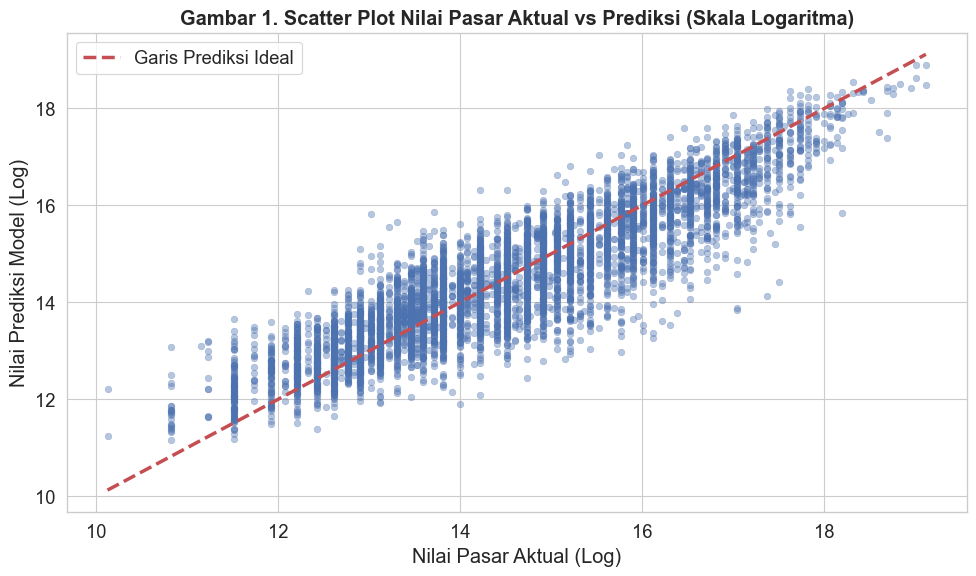

Analisis Gbr 1: Pola linier ketat menunjukkan model memiliki bias yang rendah dan varians yang baik (Goodness of Fit).


In [13]:
# ==================================================================================================
# VISUALISASI TAMBAHAN (KEBUTUHAN JURNAL AKADEMIS)
# ==================================================================================================
print("\n" + "="*80)
print("📊 GENERATING ACADEMIC PLOTS UNTUK JURNAL")
print("="*80)

# --- FIG 1: Scatter Plot Prediksi vs Aktual ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='log_market_value', y='predicted_log_value', data=df_master, alpha=0.4, color='#4c72b0', edgecolor=None)
plt.plot([min(y), max(y)], [min(y), max(y)], color='#c44e52', linestyle='--', linewidth=2.5, label='Garis Prediksi Ideal')
plt.title('Gambar 1. Scatter Plot Nilai Pasar Aktual vs Prediksi (Skala Logaritma)', fontweight='bold')
plt.xlabel('Nilai Pasar Aktual (Log)')
plt.ylabel('Nilai Prediksi Model (Log)')
plt.legend()
plt.tight_layout()
plt.show()
print("Analisis Gbr 1: Pola linier ketat menunjukkan model memiliki bias yang rendah dan varians yang baik (Goodness of Fit).")

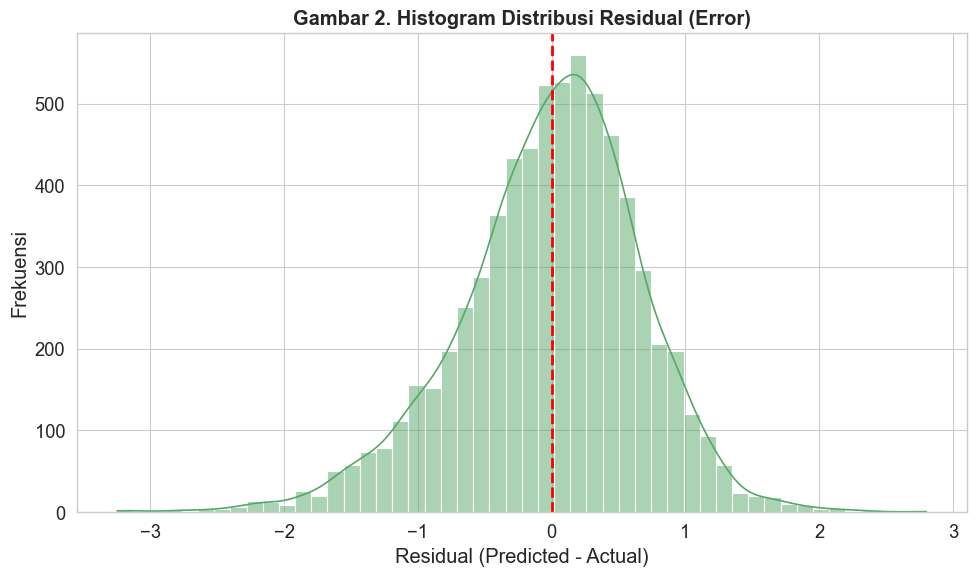

Analisis Gbr 2: Distribusi error berbentuk lonceng (Normal) dengan mean mendekati nol, memenuhi asumsi regresi.


In [14]:
# --- FIG 2: Distribusi Residual ---
plt.figure(figsize=(10, 6))
residuals = df_master['predicted_log_value'] - df_master['log_market_value']
sns.histplot(residuals, kde=True, color='#55a868', bins=50)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title('Gambar 2. Histogram Distribusi Residual (Error)', fontweight='bold')
plt.xlabel('Residual (Predicted - Actual)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()
print("Analisis Gbr 2: Distribusi error berbentuk lonceng (Normal) dengan mean mendekati nol, memenuhi asumsi regresi.")

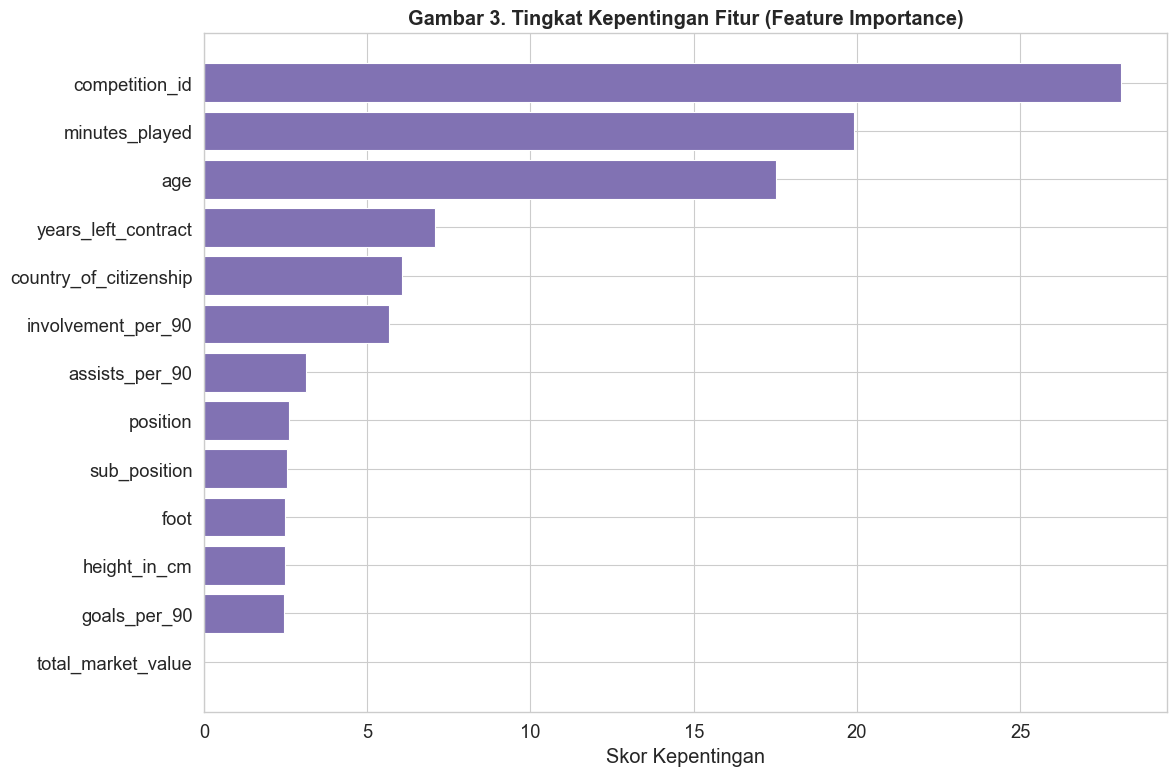

Analisis Gbr 3: Validasi variabel mana yang menjadi determinan utama dalam pembentukan harga pasar.


In [15]:
# --- FIG 3: Feature Importance ---
feature_importance = cat_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='#8172b3')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('Gambar 3. Tingkat Kepentingan Fitur (Feature Importance)', fontweight='bold')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()
print("Analisis Gbr 3: Validasi variabel mana yang menjadi determinan utama dalam pembentukan harga pasar.")

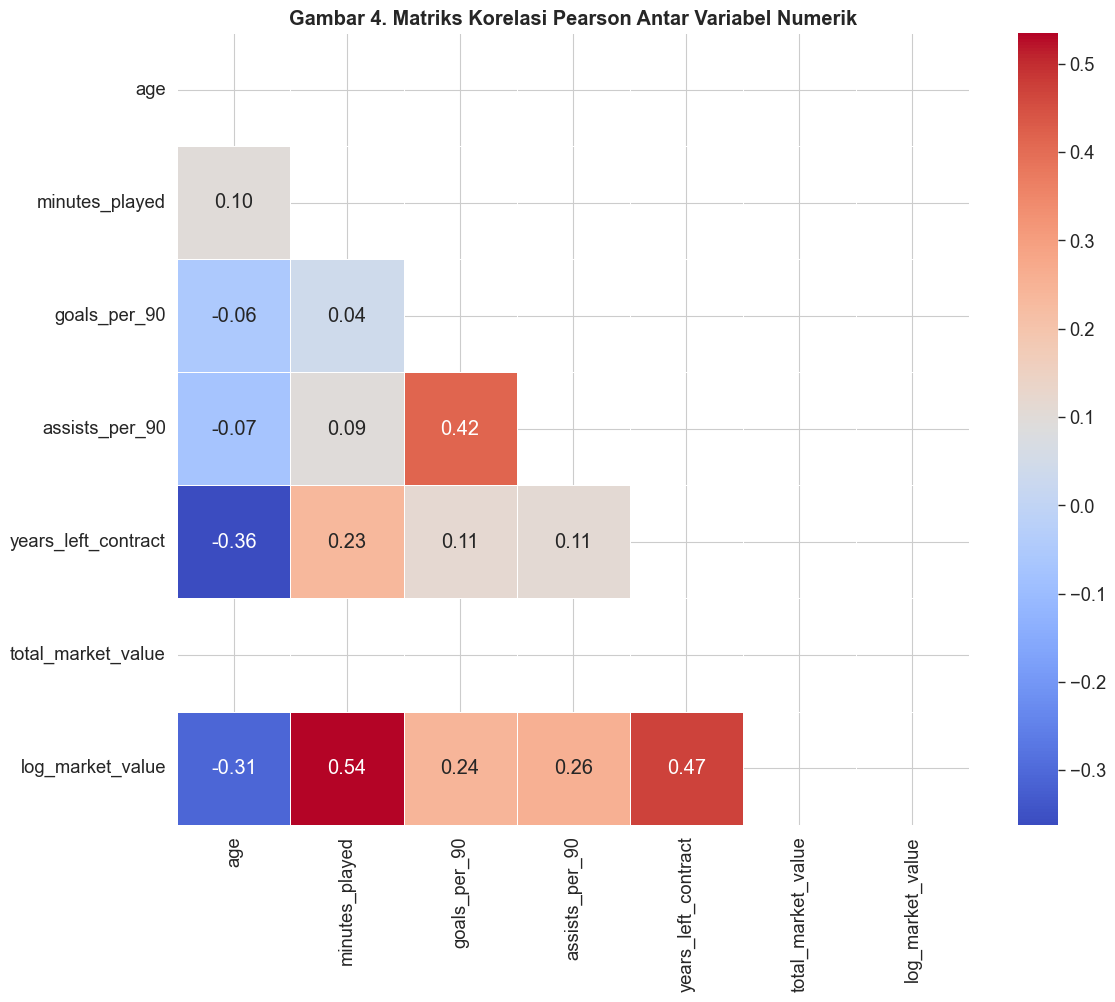

Analisis Gbr 4: Menunjukkan multikolinearitas antar fitur dan kekuatan hubungan linear terhadap target (log_market_value).


In [16]:
# --- FIG 4: Heatmap Korelasi Pearson (BARU) ---
plt.figure(figsize=(12, 10))
# Pilih kolom numerik penting untuk korelasi
corr_cols = ['age', 'minutes_played', 'goals_per_90', 'assists_per_90', 
             'years_left_contract', 'total_market_value', 'log_market_value']
corr_matrix = df_master[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Mask bagian atas segitiga
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True)
plt.title('Gambar 4. Matriks Korelasi Pearson Antar Variabel Numerik', fontweight='bold')
plt.tight_layout()
plt.show()
print("Analisis Gbr 4: Menunjukkan multikolinearitas antar fitur dan kekuatan hubungan linear terhadap target (log_market_value).")

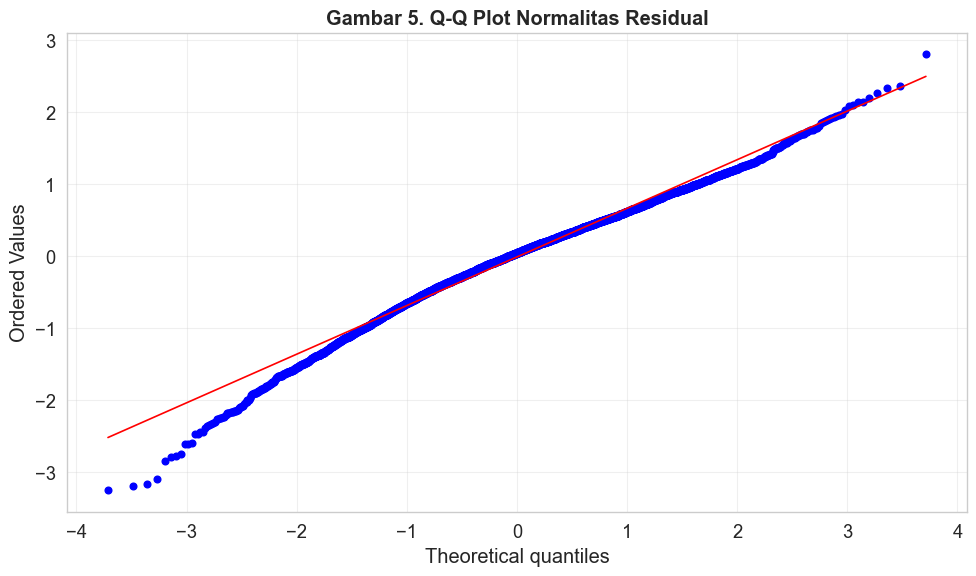

Analisis Gbr 5: Titik-titik yang mengikuti garis merah mengonfirmasi bahwa residual terdistribusi secara normal (Gaussian).


In [17]:
# --- FIG 5: QQ Plot Normality Test (BARU) ---
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Gambar 5. Q-Q Plot Normalitas Residual', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Analisis Gbr 5: Titik-titik yang mengikuti garis merah mengonfirmasi bahwa residual terdistribusi secara normal (Gaussian).")

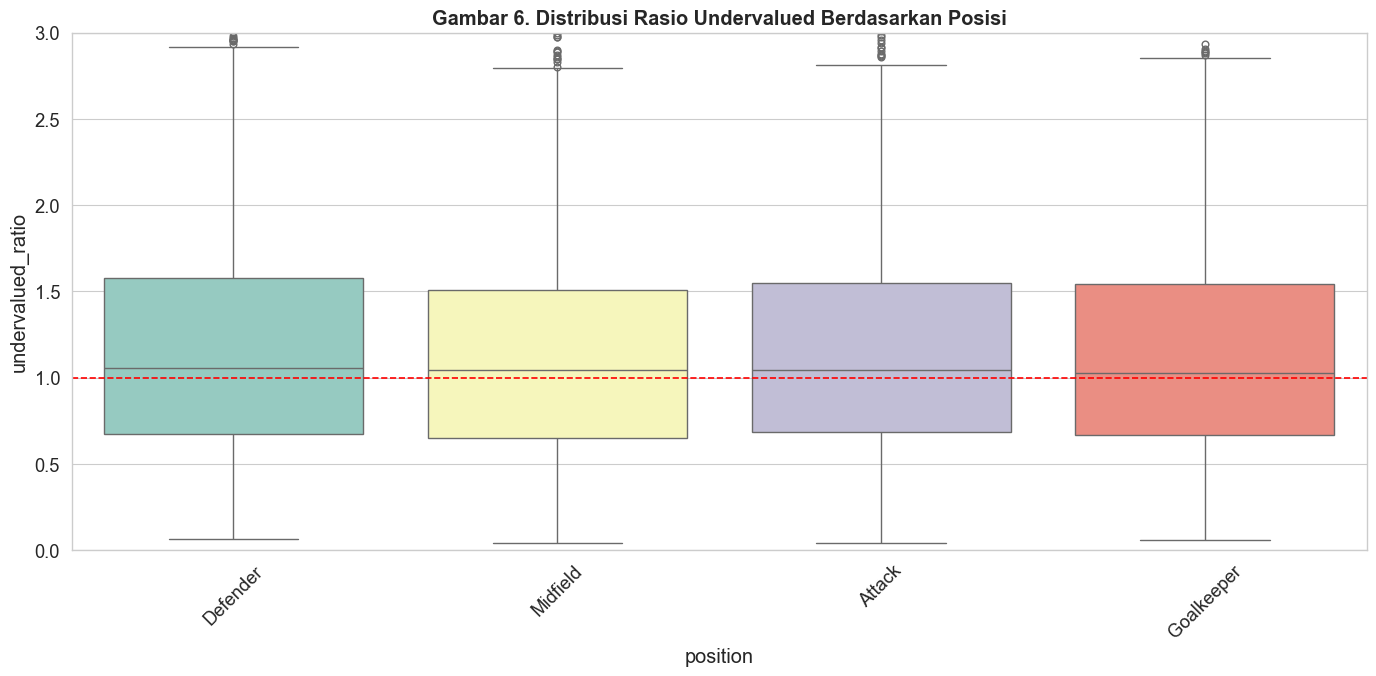

Analisis Gbr 6: Mengidentifikasi posisi pemain yang secara sistematis dinilai lebih rendah (undervalued) oleh pasar.


In [18]:
# --- FIG 6: Boxplot Undervalued Ratio per Posisi ---
plt.figure(figsize=(14, 7))
order = df_master.groupby('position')['undervalued_ratio'].median().sort_values(ascending=False).index
sns.boxplot(x='position', y='undervalued_ratio', data=df_master, order=order, palette='Set3')
plt.axhline(1.0, color='red', linestyle='--', label='Garis Harga Wajar')
plt.title('Gambar 6. Distribusi Rasio Undervalued Berdasarkan Posisi', fontweight='bold')
plt.ylim(0, 3) 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Analisis Gbr 6: Mengidentifikasi posisi pemain yang secara sistematis dinilai lebih rendah (undervalued) oleh pasar.")

In [ ]:
# ==================================================================================================
# INTERACTIVE FILTER (WIDGETS)
# ==================================================================================================
print("\n" + "="*80)
print("🎛️  DASHBOARD INTERAKTIF: FILTER PEMAIN UNDERVALUED")
print("="*80)

try:
    import ipywidgets as widgets

    # Persiapan Data untuk Dropdown
    comp_map = df_competitions.set_index('competition_id')['name'].to_dict()
    df_master['competition_name'] = df_master['domestic_competition_id'].map(comp_map).fillna('Unknown')

    unique_leagues = sorted(df_master['competition_name'].unique().astype(str))
    unique_countries = sorted(df_master['country_of_citizenship'].unique().astype(str))
    unique_positions = sorted(df_master['position'].unique().astype(str))

    unique_leagues.insert(0, 'All Leagues')
    unique_countries.insert(0, 'All Countries')
    unique_positions.insert(0, 'All Positions')

    style = {'description_width': 'initial'}
    
    league_dropdown = widgets.Dropdown(options=unique_leagues, value='All Leagues', description='🏆 Liga:', style=style)
    country_dropdown = widgets.Dropdown(options=unique_countries, value='All Countries', description='🌍 Negara:', style=style)
    position_dropdown = widgets.Dropdown(options=unique_positions, value='All Positions', description='🏃 Posisi:', style=style)
    
    output_table = widgets.Output()

    def filter_undervalued_players(change):
        league = league_dropdown.value
        country = country_dropdown.value
        position = position_dropdown.value
        
        filtered_df = df_master.copy()
        
        if league != 'All Leagues':
            filtered_df = filtered_df[filtered_df['competition_name'] == league]
        if country != 'All Countries':
            filtered_df = filtered_df[filtered_df['country_of_citizenship'] == country]
        if position != 'All Positions':
            filtered_df = filtered_df[filtered_df['position'] == position]
            
        res = filtered_df[
            (filtered_df['market_value_in_eur'] > 1000000) & 
            (filtered_df['value_gap_eur'] > 0)
        ].sort_values('value_gap_eur', ascending=False).head(20)
        
        cols_widget = ['name', 'age', 'position', 'current_club_name', 'competition_name', 
                       'market_value_in_eur', 'fair_value_eur', 'value_gap_eur', 'undervalued_ratio']
        
        display_res = res[cols_widget].copy()
        display_res.rename(columns={'name': 'player_name'}, inplace=True)
        
        display_res['market_value_in_eur'] = display_res['market_value_in_eur'].apply(lambda x: f"€{x:,.0f}")
        display_res['fair_value_eur'] = display_res['fair_value_eur'].apply(lambda x: f"€{x:,.0f}")
        display_res['value_gap_eur'] = display_res['value_gap_eur'].apply(lambda x: f"+€{x:,.0f}")
        display_res['undervalued_ratio'] = display_res['undervalued_ratio'].apply(lambda x: f"{x:.2f}x")
        
        with output_table:
            clear_output()
            if display_res.empty:
                print("❌ Tidak ada pemain yang cocok dengan kriteria filter tersebut.")
            else:
                print(f"✅ Menampilkan Top {len(display_res)} Pemain Undervalued berdasarkan filter:")
                display(display_res)

    league_dropdown.observe(filter_undervalued_players, names='value')
    country_dropdown.observe(filter_undervalued_players, names='value')
    position_dropdown.observe(filter_undervalued_players, names='value')

    print("Silakan pilih filter di bawah ini untuk melihat daftar pemain:")
    input_box = widgets.HBox([league_dropdown, country_dropdown, position_dropdown])
    display(widgets.VBox([input_box, output_table]))
    
    filter_undervalued_players(None)

except ImportError:
    print("⚠️ Modul ipywidgets tidak ditemukan. Interaktivitas dimatikan.")
except Exception as e:
    print(f"⚠️ Terjadi kesalahan pada widget: {e}")

print("\n✅ Analisis Selesai. Data siap digunakan untuk laporan jurnal.")


🎛️  DASHBOARD INTERAKTIF: FILTER PEMAIN UNDERVALUED
Silakan pilih filter di bawah ini untuk melihat daftar pemain:



✅ Analisis Selesai. Data siap digunakan untuk laporan jurnal.
